In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'  # 指定支持中文的字体
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['axes.unicode_minus'] = False  # 正确显示负号

- **导入必要的类**:

    - `SparkConf`: 用于配置 Spark 应用程序。

     - `SparkContext`: 用于创建 RDD 和执行各种 Spark 操作（旧版 API-->旧版入口点）。

    - `SparkSession`: 它封装了 SparkContext 和 SQLContext/HiveContext。-->PySpark 的入口点是 SparkSession

- **定义 Master URL**:

    - `master = "local[*]"`: 这表示 Spark 将在本地模式下运行，并使用所有可用的逻辑核心作为工作线程。
    - `master = "local[10]"`: 这表示 Spark 将在本地模式下运行，并精确使用 10 个工作线程（或核心）。

- **定义应用程序名称**:

    - `app_name = "Introduction to Apache Spark"`: 这是在 Spark Web UI 上显示的应用程序名称，有助于识别和监控你的应用程序。

In [2]:
# Import SparkConf class into program
from pyspark import SparkConf

# local[*]: run Spark in local mode with as many working processors as logical cores on your machine
# If we want Spark to run locally with 'k' worker threads, we can specify as "local[k]".
# master = "local[*]"
master = "local[10]"
# The `appName` field is a name to be shown on the Spark cluster UI page
app_name = "Introduction to Apache Spark"
# Setup configuration parameters for Spark
spark_conf = SparkConf().setMaster(master).setAppName(app_name)


- **初始化 SparkContext 或 SparkSession**

    - Method 1 : `SparkSession` :可以访问所有 Spark 功能（包括 DataFrame 和 SQL）。

        - `getOrCreate() 方法`会检查是否存在一个活动的 SparkSession，如果存在则返回它，否则创建一个新的。

        - 如果完成了所有操作，要停止 SparkSession --> `spark.stop()` 

    - Method 2 : 直接获取或实例化 `SparkContext` : 这种方式直接获取或创建一个 SparkContext。主要用于使用 RDD API 并且不需要 DataFrame 或 SQL 功能，或者为了兼容旧代码。

- **设置日志级别**:

    - `sc.setLogLevel('ERROR')`: 这将 Spark 的日志级别设置为 ERROR。这意味着只有错误级别的日志消息会被打印到控制台，从而减少冗余的输出，

In [3]:
# Import SparkContext and SparkSession classes
from pyspark import SparkContext # Spark
from pyspark.sql import SparkSession # Spark SQL

# Method 1: Using SparkSession
spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()
sc = spark.sparkContext
sc.setLogLevel('ERROR')

# Method 2: Getting or instantiating a SparkContext
# sc = SparkContext.getOrCreate(spark_conf)
# sc.setLogLevel('ERROR')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/08/02 23:31:01 WARN Utils: Your hostname, Jiayis-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.3.146 instead (on interface en0)
25/08/02 23:31:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/02 23:31:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Loading data

`header=True` 表示第一行是列名

`inferSchema=True` 表示 Spark 会尝试自动推断列的数据类型

In [4]:
attribute_file_path = '/Users/jiayiliu/Desktop/bigdata_project/obesity_level/obesity_level_attribute.csv'
result_file_path = '/Users/jiayiliu/Desktop/bigdata_project/obesity_level/obesity_level_result.csv'

# Reading CSV files using SparkSession
Attribute_df = spark.read.csv(attribute_file_path, header=True, inferSchema=True)
Result_df = spark.read.csv(result_file_path, header=True, inferSchema=True)


`show() 方法` : 显示 DataFrame 的前 20 行

In [5]:
# 查看前 5 行
Attribute_df.show(5)

+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+
|    id|Gender|      Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|
+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+
|678333|  Male|     33.0|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile|
|648332|Female|     18.0|    1.58|  39.0|                             0|   1| 2.8|3.0| Sometimes|    0|     2.0|  0|     2.0|1.0|Sometimes|Public_Transporta...|
|495333|Female|19.773303|1.602082|  45.0|                             0|   0| 3.0|3.0|Frequently|    0|2.875583|  1|1.269169|0.0|Sometimes|Public_Transporta...|
|155635|Female|     22.0|    1.71|

In [6]:
# 查看前 5 行
Result_df.show(5)

+------+-------------------+
|    id|            0be1dad|
+------+-------------------+
|678333| Overweight_Level_I|
|648332|Insufficient_Weight|
|495333|Insufficient_Weight|
|155635| Overweight_Level_I|
|909431|Insufficient_Weight|
+------+-------------------+
only showing top 5 rows


##### **Report**：
通过观察发现：Obesity_level列名不对，需修改

### 1.merge data

#### 根据id合并两个Attribute_df和Result_df生成data

**JOIN 并不是自动合并相同列，而是取决于你如何指定 JOIN 条件**：

- **布尔表达式**：它会保留所有列`Attribute.join(Result, Attribute.id == Result.id, "inner")`:

    - Attribute 和 Result 是两个 DataFrame。

    - Attribute.id == Result.id 是连接条件，表示基于 id 列进行连接。
         - 内连接（inner join）\ 外连接(outer) \ 左外连接（left_outer）\ 右外连接（right_outer）\ 左半连接（left_semi : `Z返回左边 DataFrame 中与右边 DataFrame 匹配的行，但不包含右边 DataFrame 的列）。

- **on="col_name"**: 只保留一个连接键列(适用只有一个共同的列名)`Attribute_df.join(Result_df, on="id", how="inner")`
    - 如果有多个共同列：需使用 drop 或 select 来处理它们

In [7]:
data = Attribute_df.join(Result_df, on="id", how="inner")

#### 查看data前5行

In [8]:
data.show(5)

+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+
|    id|Gender|      Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|            0be1dad|
+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+
|678333|  Male|     33.0|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile| Overweight_Level_I|
|648332|Female|     18.0|    1.58|  39.0|                             0|   1| 2.8|3.0| Sometimes|    0|     2.0|  0|     2.0|1.0|Sometimes|Public_Transporta...|Insufficient_Weight|
|495333|Female|19.773303|1.602082|  45.0|                             0|   0| 3.0|3.0|Frequentl

##### **Report**：
通过观察发现，‘Age’列中的值带小数点，为了方便观察分析，需将其四舍五入

#### 查看DataFrame的结构

`printSchema() 方法` : 查看 DataFrame 的结构，包括列名、数据类型和嵌套结构

**ps**:

data.dtypes --> 查看每列的数据类型

data.columns --> 查看列名


In [9]:
data.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- Height: double (nullable = true)
 |-- Weight: double (nullable = true)
 |-- family_history_with_overweight: integer (nullable = true)
 |-- FAVC: integer (nullable = true)
 |-- FCVC: double (nullable = true)
 |-- NCP: double (nullable = true)
 |-- CAEC: string (nullable = true)
 |-- SMOKE: integer (nullable = true)
 |-- CH2O: double (nullable = true)
 |-- SCC: integer (nullable = true)
 |-- FAF: double (nullable = true)
 |-- TUE: double (nullable = true)
 |-- CALC: string (nullable = true)
 |-- MTRANS: string (nullable = true)
 |-- 0be1dad: string (nullable = true)



#### 描述性统计信息

`describe() 方法`用于生成描述性统计信息 --> 使用 show() 方法来显示这些统计信息

In [10]:
data.describe().show()

+-------+------------------+------+------------------+-------------------+------------------+------------------------------+------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+---------+----------+-------------------+
|summary|                id|Gender|               Age|             Height|            Weight|family_history_with_overweight|              FAVC|              FCVC|               NCP|     CAEC|               SMOKE|              CH2O|                SCC|               FAF|               TUE|     CALC|    MTRANS|            0be1dad|
+-------+------------------+------+------------------+-------------------+------------------+------------------------------+------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+---------+----------+-------------------+
|  coun

##### **Report**：
通过观察，发现 ‘肥胖水平列’出现了‘0rmal_Weight',应该将其更改为‘Normal_Weight’

#### 计算每一列的唯一值数量

`distinct` 和 `count 方法`计算每列的精确唯一值数量

In [11]:
unique_values_count = {col: data.select(col).distinct().count() for col in data.columns}

# 打印结果
unique_values_count

{'id': 20789,
 'Gender': 2,
 'Age': 1711,
 'Height': 1843,
 'Weight': 1991,
 'family_history_with_overweight': 2,
 'FAVC': 2,
 'FCVC': 934,
 'NCP': 689,
 'CAEC': 4,
 'SMOKE': 2,
 'CH2O': 1506,
 'SCC': 2,
 'FAF': 1360,
 'TUE': 1297,
 'CALC': 3,
 'MTRANS': 5,
 '0be1dad': 8}

##### **Report**：
‘Age’/‘Height’/‘Weight’/‘FAF’等字段的数量过多，容易在可视化过程中出现不易观察不易理解的问题，所以需要进行数据范围划分。

#### 查看非数值类型列的唯一值

不要写`from pyspark.sql.types import *` ，不要导 * （*是指全部），需要什么类型需指定

In [12]:
from pyspark.sql.types import IntegerType, LongType, FloatType, DoubleType, DecimalType, ByteType, ShortType 

`distinct() `用于获取唯一的行，这里我们只选择一列，所以就是该列的唯一值

`collect() `将结果拉取到驱动程序作为 Python 列表

In [13]:
# 识别非数值类型列
non_numeric_cols = []
numeric_types = (IntegerType, LongType, FloatType, DoubleType, DecimalType, ByteType, ShortType)

for field in data.schema:
    if not isinstance(field.dataType, numeric_types):
        non_numeric_cols.append(field.name)

print(f"\n--- 识别到的非数值类型列: {non_numeric_cols} ---")
for col_name in non_numeric_cols:
    print(f"\n列名: '{col_name}'")

    # 获取列的数据类型
    col_dtype = data.schema[col_name].dataType
    print(f"数据类型: {col_dtype}")
     # 获取唯一值
    unique_values_rows = data.select(col_name).distinct().collect()

    # 从 Row 对象中提取实际的值
    unique_values = [row[col_name] for row in unique_values_rows]
    num_unique = len(unique_values)

    print(f"唯一值数量: {num_unique}")
    print(f"唯一值列表: {unique_values}")



--- 识别到的非数值类型列: ['Gender', 'CAEC', 'CALC', 'MTRANS', '0be1dad'] ---

列名: 'Gender'
数据类型: StringType()
唯一值数量: 2
唯一值列表: ['Female', 'Male']

列名: 'CAEC'
数据类型: StringType()
唯一值数量: 4
唯一值列表: ['Sometimes', '0', 'Frequently', 'Always']

列名: 'CALC'
数据类型: StringType()
唯一值数量: 3
唯一值列表: ['Sometimes', '0', 'Frequently']

列名: 'MTRANS'
数据类型: StringType()
唯一值数量: 5
唯一值列表: ['Bike', 'Walking', 'Automobile', 'Motorbike', 'Public_Transportation']

列名: '0be1dad'
数据类型: StringType()
唯一值数量: 8
唯一值列表: ['Obesity_Type_III', 'Overweight_Level_I', '0rmal_Weight', 'Obesity_Type_II', 'Insufficient_Weight', 'Overweight_Level_II', 'Normal_Weight', 'Obesity_Type_I']


##### **Report**：
‘CAEC’和‘CALC’这两个字段中出现数值0，与其他值不符合；又根据唯一值数量分别为4和3，可以判断0就是没有的意思，所以需要把它修改为Never 。

### 2. Clear Data

#### 2.1 Remove Unnecessary Columns and Fix Column Names

#### 重命名 data 中的Obesity_level列

In [14]:
data = data.withColumnRenamed("0be1dad", "Obesity_level" )

In [15]:
from pyspark.sql.functions import when , col

#### 将Obesity_level 列中的 ormal_Weight 值改为 Normal_Weight

In [16]:
data= data.withColumn("Obesity_level", 
                           when(col("Obesity_level") == "0rmal_Weight", "Normal_Weight")
                           .otherwise(col("Obesity_level")))

In [17]:
# 指定列名
columns_to_check = ['Obesity_level']

# 查看指定列的不同值及其具体内容
for column in columns_to_check:
    print(f"字段名: {column}")
    
    # 获取不同值及其数量
    value_counts = data.groupBy(column).count().orderBy(col("count").desc())
    print(f"不同值及其数量:")
    value_counts.show()

字段名: Obesity_level
不同值及其数量:
+-------------------+-----+
|      Obesity_level|count|
+-------------------+-----+
|   Obesity_Type_III| 4046|
|    Obesity_Type_II| 3248|
|      Normal_Weight| 3096|
|     Obesity_Type_I| 2913|
|Insufficient_Weight| 2530|
|Overweight_Level_II| 2529|
| Overweight_Level_I| 2427|
+-------------------+-----+



#### 2.2 Transfer Data Type

#### Age 四舍五入取整（round）

`round()` 函数来对数值进行四舍五入

`cast() `函数将列的数据类型转换为整数类型

In [18]:
from pyspark.sql.functions import round as round_func
from pyspark.sql.types import IntegerType

In [19]:
data = data.withColumn("Age", round_func(col("Age")).cast(IntegerType()))
data.select("Age").head(5)

[Row(Age=33), Row(Age=18), Row(Age=20), Row(Age=22), Row(Age=19)]

#### CAEC\CALC 中的 '0' 改为 'Never'

`replace() 函数`来替换 DataFrame 中的值

In [20]:
data = data.withColumn("CAEC", when(col("CAEC") == "0", "Never").otherwise(col("CAEC")))
data = data.withColumn("CALC", when(col("CALC") == "0", "Never").otherwise(col("CALC")))

In [21]:
print("\nCAEC 的不同值及其数量：")
caec_counts = data.groupBy("CAEC").count().orderBy(col("count").desc())
caec_counts.show()

print("\nCALC 的不同值及其数量：")
calc_counts = data.groupBy("CALC").count().orderBy(col("count").desc())
calc_counts.show()


CAEC 的不同值及其数量：
+----------+-----+
|      CAEC|count|
+----------+-----+
| Sometimes|17553|
|Frequently| 2479|
|    Always|  478|
|     Never|  279|
+----------+-----+


CALC 的不同值及其数量：
+----------+-----+
|      CALC|count|
+----------+-----+
| Sometimes|15085|
|     Never| 5171|
|Frequently|  533|
+----------+-----+



#### 2.3 Duplicate

#### 检查 ID 列是否有重复值

In [22]:
# 计算每个 id 的出现次数
id_counts = data.groupBy('id').count()

# 过滤出出现次数大于 1 的 id
duplicate_ids = id_counts.filter("count > 1").select('id')

# 检查 data 中是否存在重复的 id
if duplicate_ids.count() > 0:
    print("ID 列有重复值。")
else:
    print("ID 列的值是唯一的。")

ID 列的值是唯一的。


#### 检查所有行中重复的行

In [23]:
# 计算每行的重复次数
row_counts = data.groupBy(*data.columns).count()

# 筛选出重复次数大于1的行
duplicate_rows = row_counts.filter(row_counts['count'] > 1)

# 计算重复行的数量
duplicate_rows_count = duplicate_rows.count()

print(f"数据集中重复行的数量为：{duplicate_rows_count}")


数据集中重复行的数量为：0


#### 2.4 Empty Lines

#### 检查每列的缺失值数量

In [24]:
for column in data.columns:
    null_count = data.filter(data[column].isNull()).count()
    print(f"列 '{column}' 中缺失值的数量为：{null_count}")

列 'id' 中缺失值的数量为：0
列 'Gender' 中缺失值的数量为：0
列 'Age' 中缺失值的数量为：0
列 'Height' 中缺失值的数量为：0
列 'Weight' 中缺失值的数量为：0
列 'family_history_with_overweight' 中缺失值的数量为：0
列 'FAVC' 中缺失值的数量为：0
列 'FCVC' 中缺失值的数量为：0
列 'NCP' 中缺失值的数量为：0
列 'CAEC' 中缺失值的数量为：0
列 'SMOKE' 中缺失值的数量为：0
列 'CH2O' 中缺失值的数量为：0
列 'SCC' 中缺失值的数量为：0
列 'FAF' 中缺失值的数量为：0
列 'TUE' 中缺失值的数量为：0
列 'CALC' 中缺失值的数量为：0
列 'MTRANS' 中缺失值的数量为：0
列 'Obesity_level' 中缺失值的数量为：0


#### 检查每列的零值数量

在 PySpark 中，不能够将字符串类型的值（如 'Male'）与数字 0 进行比较，因为 PySpark 无法将字符串自动转换为数字。

In [25]:
# 检查每一列是否存在零值
for column in data.columns:
    # 获取列的数据类型
    column_type = data.schema[column].dataType.typeName()
    
    # 检查列是否为数值类型
    if column_type in ['integer', 'long', 'double', 'float', 'short', 'byte', 'decimal']:
        # 筛选出每列中值为 0 的行
        zero_count = data.filter(col(column) == 0).count()
        print(f"列 '{column}' 中零值的数量为：{zero_count}")
    else:
        print(f"列 '{column}' 不是数值类型，跳过零值检查。")

列 'id' 中零值的数量为：0
列 'Gender' 不是数值类型，跳过零值检查。
列 'Age' 中零值的数量为：0
列 'Height' 中零值的数量为：0
列 'Weight' 中零值的数量为：2
列 'family_history_with_overweight' 中零值的数量为：3747
列 'FAVC' 中零值的数量为：1776
列 'FCVC' 中零值的数量为：0
列 'NCP' 中零值的数量为：0
列 'CAEC' 不是数值类型，跳过零值检查。
列 'SMOKE' 中零值的数量为：20544
列 'CH2O' 中零值的数量为：0
列 'SCC' 中零值的数量为：20102
列 'FAF' 中零值的数量为：5059
列 'TUE' 中零值的数量为：6569
列 'CALC' 不是数值类型，跳过零值检查。
列 'MTRANS' 不是数值类型，跳过零值检查。
列 'Obesity_level' 不是数值类型，跳过零值检查。


#### 2.5 Drop Outliers

#### 绘制箱型图，查看异常值

**箱型图**  

- 箱子内部的那条粗线 --> `中位数`

- 箱体 --> 由第一四分位数 (Q1) 和 第三四分位数 (Q3) 构成
    - IQR = Q3 - Q1

    - `Q1 (下边缘)`：箱子的底部，代表数据集的第 `25 %` --> 这意味着 25% 的数据点低于这个值。

    - `Q3 (上边缘)`：箱子的顶部，代表数据集的第 `75 %` --> 这意味着 75% 的数据点低于这个值，或者说 25% 的数据点高于这个值。

- 胡须 / 从箱子顶部和底部延伸出的两条线 --> 离箱子远但`仍在合理范围内`
    
    - `上限胡须`： Q3 + 1.5 * IQR 的最大值（或数据集中的最大值，如果它小于 Q3 + 1.5 * IQR）。

    - `下限胡须`： Q1 - 1.5 * IQR 的最小值（或数据集中的最小值，如果它大于 Q1 - 1.5 * IQR）

- 胡须之外的独立点或圆圈 --> `异常值`
    - 小于 (Q1 - 1.5 * IQR) 或大于 (Q3 + 1.5 * IQR)

In [26]:
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType, ShortType, ByteType, DecimalType

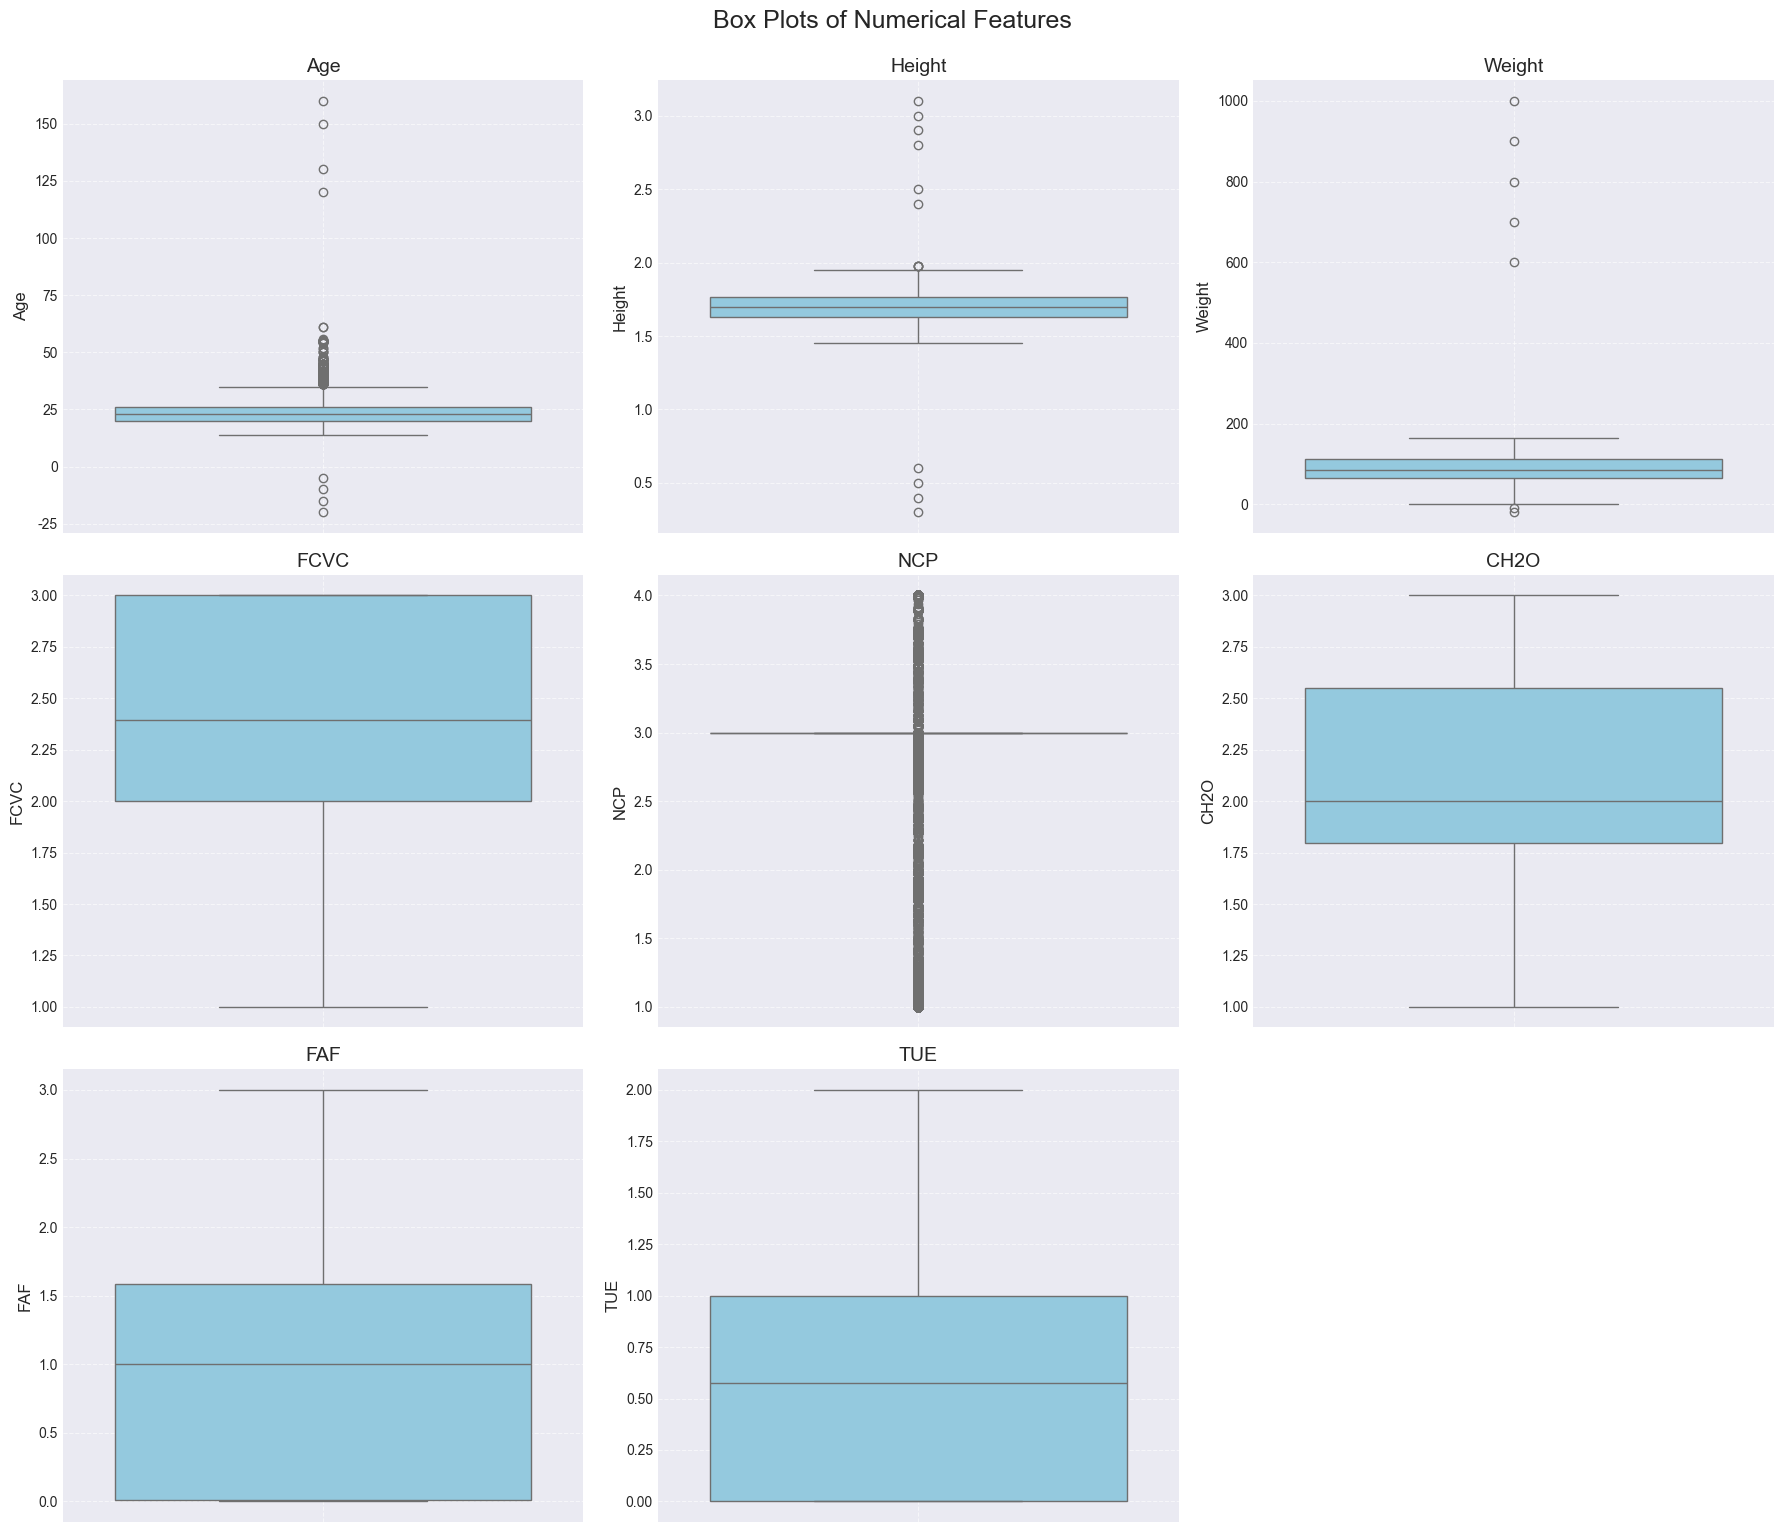

In [27]:
# 明确列出所有数值型字段
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

# 设置 Matplotlib 样式
plt.style.use('seaborn-v0_8-darkgrid') # 使用 seaborn 样式

# 创建一个图形和轴
fig, axes = plt.subplots(nrows=(len(numeric_cols) + 2) // 3, ncols=3, figsize=(18, 5 * ((len(numeric_cols) + 2) // 3)))
axes = axes.flatten() # 将 axes 转换为一维数组，方便迭代

# 遍历所有数值列并绘制箱型图
for i, col in enumerate(numeric_cols):
    if i < len(axes): # 确保索引不越界
        # 将 PySpark DataFrame 的单列转换为 Pandas Series
        # 使用 toPandas() 会将数据拉取到Driver，数据量大时需谨慎
        pdf_series = data.select(col).toPandas()[col]

        # 绘制箱型图
        sns.boxplot(y=pdf_series, ax=axes[i], color='skyblue') # 使用 seaborn 绘制
        axes[i].set_title(f'{col}', fontsize=14)
        axes[i].set_ylabel(col, fontsize=12)
        axes[i].tick_params(axis='y', labelsize=10) # 调整Y轴刻度标签大小
        axes[i].grid(True, linestyle='--', alpha=0.6) # 添加网格线

# 隐藏多余的子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # 自动调整子图间距
plt.suptitle('Box Plots of Numerical Features', y=1.02, fontsize=18) # 添加总标题
plt.show()


##### **Report**:

- Age列有部分数据在upper_bound之外，其中有部分距离upper_bound很近，有可能是因为这部分的数据量太少导致的。

- NCP列表示使用主餐的次数，绝大部分值都是3，3餐/天（早餐、午餐、晚餐）是大多数人的常态。（补充：如果数据集中 50% 以上的数据是 3，那么中位数就会是 3。如果 25% 到 75% 之间的数据也都是 3，那么箱体就会变成一条线。）

#### 指定范围过滤Age列的异常值

In [28]:
from pyspark.sql.functions import col

In [29]:
filter_Age_before = data.count()
data = data.filter((col("Age") >= 0) & (col("Age") <= 100))
print(f"过滤前行数: {filter_Age_before}, 过滤后行数: {data.count()}")

过滤前行数: 20789, 过滤后行数: 20781


>存疑TODO：如果我不添加from pyspark.sql.functions import col，会有报错TypeError: 'str' object is not callable --> 是因为 col 被错误地当作字符串来调用了。可是在上面的时候我已经导入过。

#### 指定Weight和Height进行过滤异常值

In [30]:
from pyspark.sql.functions import percentile_approx

In [31]:
# 定义需要进行 IQR 异常值过滤的列
columns_for_iqr_filter = ['Height', 'Weight']
                          
# 记录过滤前的行数
filter_count_before = data.count()

# 循环遍历这些列并进行 IQR 异常值过滤
for col_name in columns_for_iqr_filter:
    
    # 计算 Q1 和 Q3
    q1_q3 = data.agg(
        percentile_approx(col(col_name), 0.25).alias("q1"),
        percentile_approx(col(col_name), 0.75).alias("q3")
    ).collect()[0]

    q1 = q1_q3.q1
    q3 = q1_q3.q3

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # 过滤异常值
    data = data.filter(
        (col(col_name) >= lower_bound) & (col(col_name) <= upper_bound)
    )

# 记录过滤后的行数并输出
df = data.count()
print(f"过滤前行数: {filter_count_before}, 过滤后行数: {df}")

过滤前行数: 20781, 过滤后行数: 20772


#### 2.6 Divide the scope

#### 对年龄Age进行范围划分

`withColumn 方法`会创建一个新的列或覆盖已存在的列

In [32]:
data = data.withColumn("AgeRange", when(col("Age") <= 12, "Child")
                              .when((col("Age") >= 13) & (col("Age") <= 17), "Teenager")
                              .when((col("Age") >= 18) & (col("Age") <= 34), "Young Adult")
                              .when((col("Age") >= 35) & (col("Age") <= 44), "Middle Age")
                              .when((col("Age") >= 45) & (col("Age") <= 54), "Mature Adult")
                              .when((col("Age") >= 55) & (col("Age") <= 64), "Senior")
                              .otherwise("Elderly"))

In [33]:
data.show(5)

+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+-----------+
|    id|Gender|Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|      Obesity_level|   AgeRange|
+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+-----------+
|678333|  Male| 33|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile| Overweight_Level_I|Young Adult|
|648332|Female| 18|    1.58|  39.0|                             0|   1| 2.8|3.0| Sometimes|    0|     2.0|  0|     2.0|1.0|Sometimes|Public_Transporta...|Insufficient_Weight|Young Adult|
|495333|Female| 20|1.602082|  45.0|                             0

#### 对每日耗水量CH2O划定范围

In [34]:
data = data.withColumn(
    'CH2O_CategoryRange',
    when((col("CH2O") >= 0) & (col("CH2O") <= 1), '0-1L')   \
    .when((col("CH2O") > 1) & (col("CH2O") <= 2), '1-2L')   \
    .when((col("CH2O") > 2) & (col("CH2O") <= 3), '2-3L')    \
    .otherwise('>3L')
)

#### 对运动频率FAF划定范围

In [35]:
data = data.withColumn("FAFRange", when(col("FAF") <= 1, "low")
                              .when((col("FAF") > 1) & (col("FAF") <= 2), "medium")
                              .when((col("FAF") > 2) & (col("FAF") <= 3), "high")
                              .otherwise("other"))

#### 对食用主餐的次数NCP划定范围

In [36]:
data = data.withColumn(
    'NCP_CategoryRange',
    when((col("NCP") >= 0) & (col("NCP") <= 1), '0-2次')   \
    .when((col("NCP") > 1) & (col("NCP") <= 2), '1-2次')   \
    .when((col("NCP") > 2) & (col("NCP") <= 3), '2-3次')    \
    .otherwise('>3次')
)

In [37]:
data.show(5)

+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+-----------+------------------+--------+-----------------+
|    id|Gender|Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|      Obesity_level|   AgeRange|CH2O_CategoryRange|FAFRange|NCP_CategoryRange|
+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+-----------+------------------+--------+-----------------+
|678333|  Male| 33|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile| Overweight_Level_I|Young Adult|              1-2L|     low|            2-3次|
|648332|Female| 18|    1.58|  39.0|                             0|   

### 2.7 describe date

####  Pie Chart

`value_counts 方法`来计算每个分类的计数

ps：

count() 方法通常用来计算 DataFrame 中的行数

#### 性别分布

+------+-----+
|Gender|count|
+------+-----+
|Female|10430|
|  Male|10342|
+------+-----+



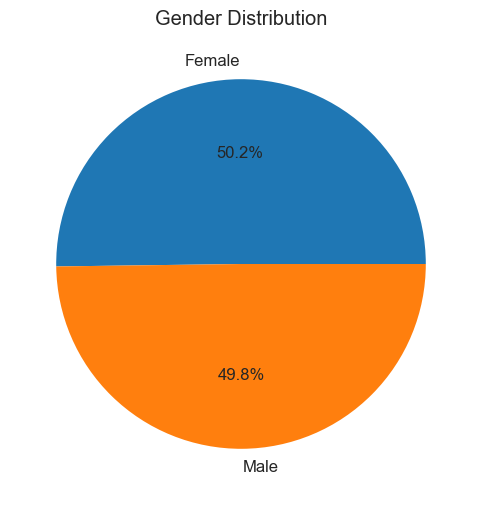

In [38]:
gender_counts = data.groupBy("Gender").count()
gender_counts.show()

# 转换为 Pandas DataFrame 以绘制饼状图
gender_counts_pd = gender_counts.toPandas()
plt.figure(figsize=(8, 6))
plt.pie(gender_counts_pd['count'], labels=gender_counts_pd['Gender'], autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

##### **Report**：
通过此饼状图，可以得知该数据集的男女比例基本平均

#### 肥胖水平分布

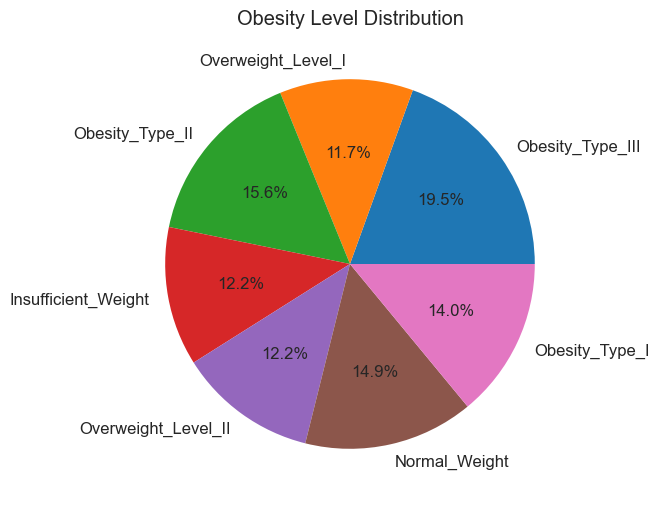

In [39]:
obesity_counts = data.groupBy("Obesity_level").count()

# 转换为 Pandas DataFrame 以绘制饼状图
obesity_counts_pd = obesity_counts.toPandas()
plt.figure(figsize=(8, 6))
plt.pie(obesity_counts_pd['count'], labels=obesity_counts_pd['Obesity_level'], autopct='%1.1f%%')
plt.title('Obesity Level Distribution')
plt.show()

##### **Report**：
通过此饼状图，可以得知该数据集的男女比例肥胖水平基本平均，其中 ‘Obesity_Type_III’比例最大

#### 性别与肥胖水平的关系

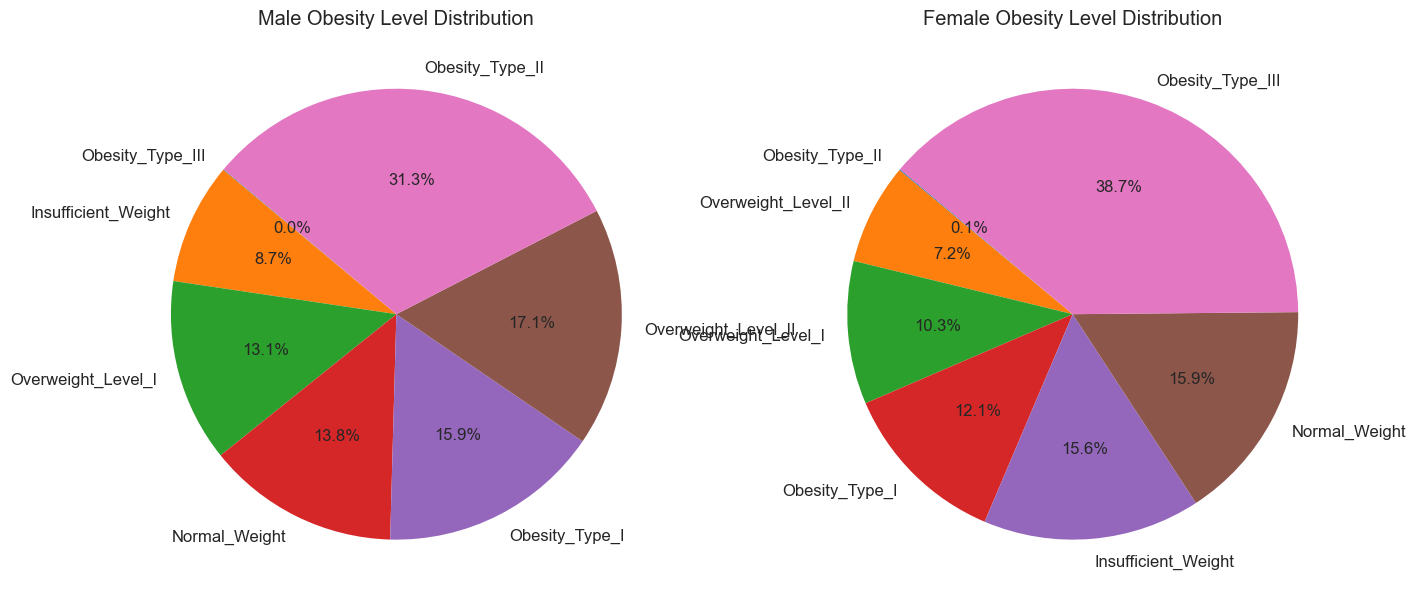

In [40]:
# 对 Gender 和 Obesity_level 字段进行聚合
gender_obesity_counts = data.groupBy("Gender", "Obesity_level").count().orderBy("Gender", "count", descending=True)

# 将聚合结果转换为 Pandas DataFrame
gender_obesity_counts_pd = gender_obesity_counts.toPandas()

# 绘制饼状图
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 男性
male_data = gender_obesity_counts_pd[gender_obesity_counts_pd['Gender'] == 'Male']
male_labels = male_data['Obesity_level']
male_sizes = male_data['count']
axes[0].pie(male_sizes, labels=male_labels, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Male Obesity Level Distribution')

# 女性
female_data = gender_obesity_counts_pd[gender_obesity_counts_pd['Gender'] == 'Female']
female_labels = female_data['Obesity_level']
female_sizes = female_data['count']
axes[1].pie(female_sizes, labels=female_labels, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Female Obesity Level Distribution')

plt.show()

##### **Report**：
通过此饼状图，可以得知该数据集中，男性女性的‘Obesity_Type_II’占比最大，‘Obesity_Type_II’占比最少

#### 日常交通方式与肥胖水平的关系

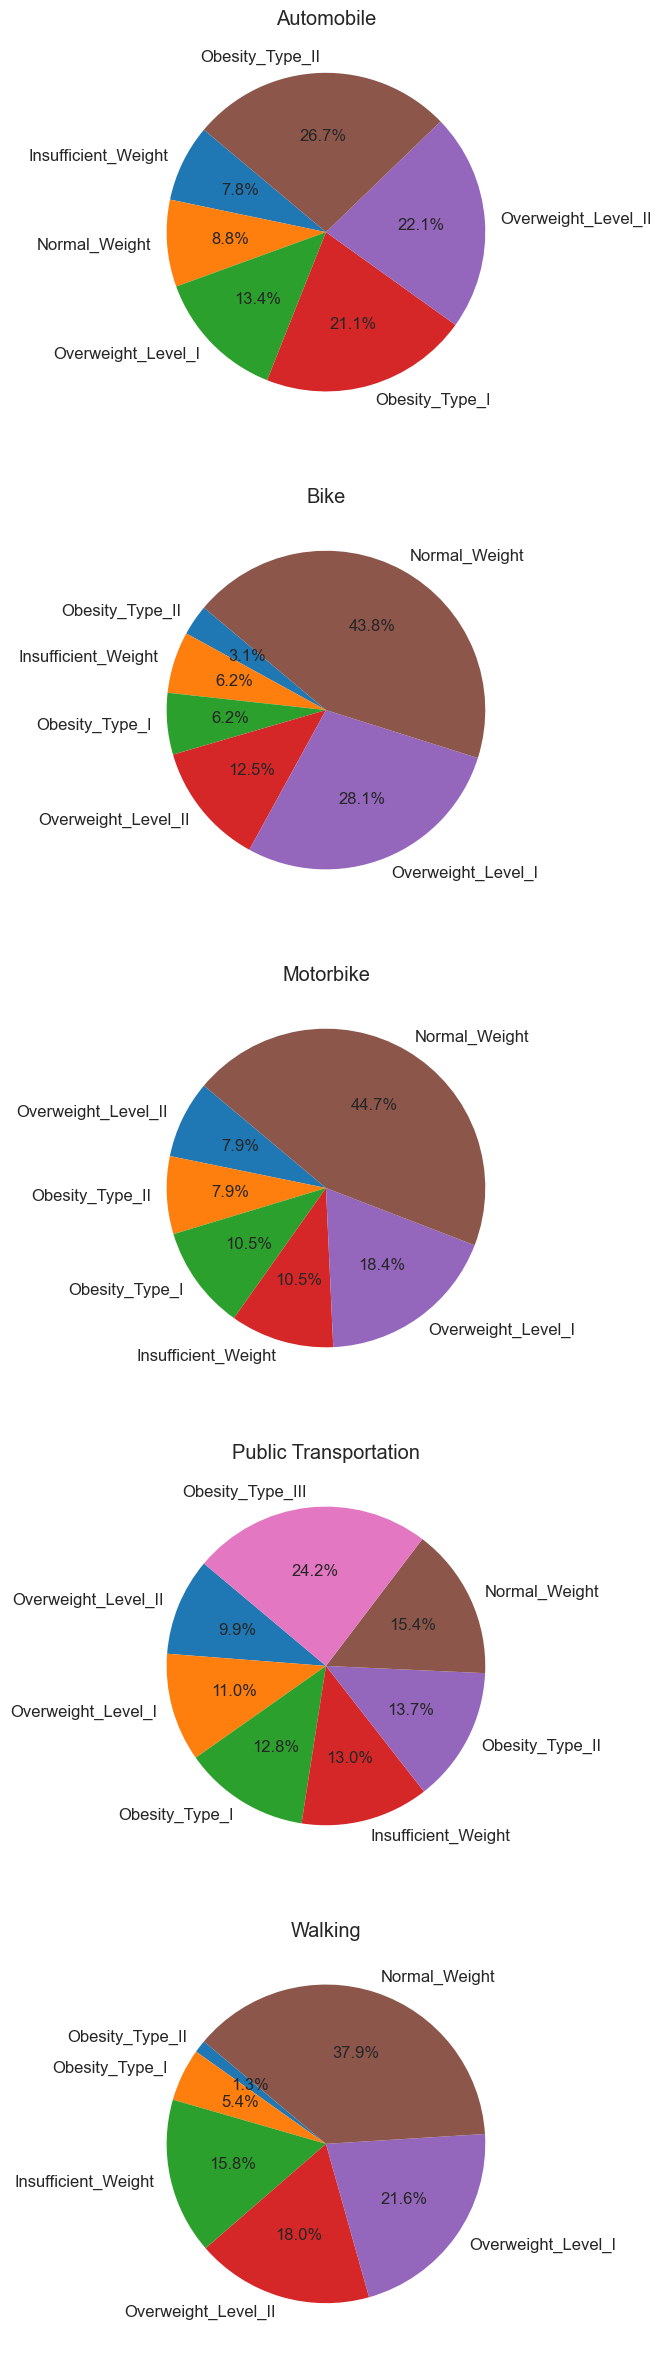

In [41]:
# 对 MTRANS 和 Obesity_level 字段进行聚合
transport_obesity_counts = data.groupBy("MTRANS", "Obesity_level").count().orderBy("MTRANS", "count", descending=True)

# 将聚合结果转换为 Pandas DataFrame
transport_obesity_counts_pd = transport_obesity_counts.toPandas()

# 绘制饼状图
fig, axes = plt.subplots(5, 1, figsize=(80, 30))

# Automobile
auto_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Automobile']
auto_labels = auto_data['Obesity_level']
auto_sizes = auto_data['count']
axes[0].pie(auto_sizes, labels=auto_labels, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Automobile')

# Bike
bike_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Bike']
bike_labels = bike_data['Obesity_level']
bike_sizes = bike_data['count']
axes[1].pie(bike_sizes, labels=bike_labels, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Bike')

# Motorbike
motorbike_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Motorbike']
motorbike_labels = motorbike_data['Obesity_level']
motorbike_sizes = motorbike_data['count']
axes[2].pie(motorbike_sizes, labels=motorbike_labels, autopct='%1.1f%%', startangle=140)
axes[2].set_title('Motorbike')

# Public Transportation
public_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Public_Transportation']
public_labels = public_data['Obesity_level']
public_sizes = public_data['count']
axes[3].pie(public_sizes, labels=public_labels, autopct='%1.1f%%', startangle=140)
axes[3].set_title('Public Transportation')

# Walking
walking_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Walking']
walking_labels = walking_data['Obesity_level']
walking_sizes = walking_data['count']
axes[4].pie(walking_sizes, labels=walking_labels, autopct='%1.1f%%', startangle=140)
axes[4].set_title('Walking')

plt.show()

##### **Report**:
使用自行车和步行的人群肥胖水平较低，而使用汽车和公共交通的人群肥胖水平较高

#### Bar Chart

#### 年龄范围与其他字段的关系

In [42]:
age_scc_counts = data.groupBy("AgeRange","SCC").count().toPandas()
age_mtrans_counts = data.groupBy("AgeRange","MTRANS").count().toPandas()
age_faf_counts = data.groupBy("AgeRange","FAFRange").count().toPandas()
age_obesity_counts = data.groupBy("AgeRange","Obesity_level").count().toPandas()

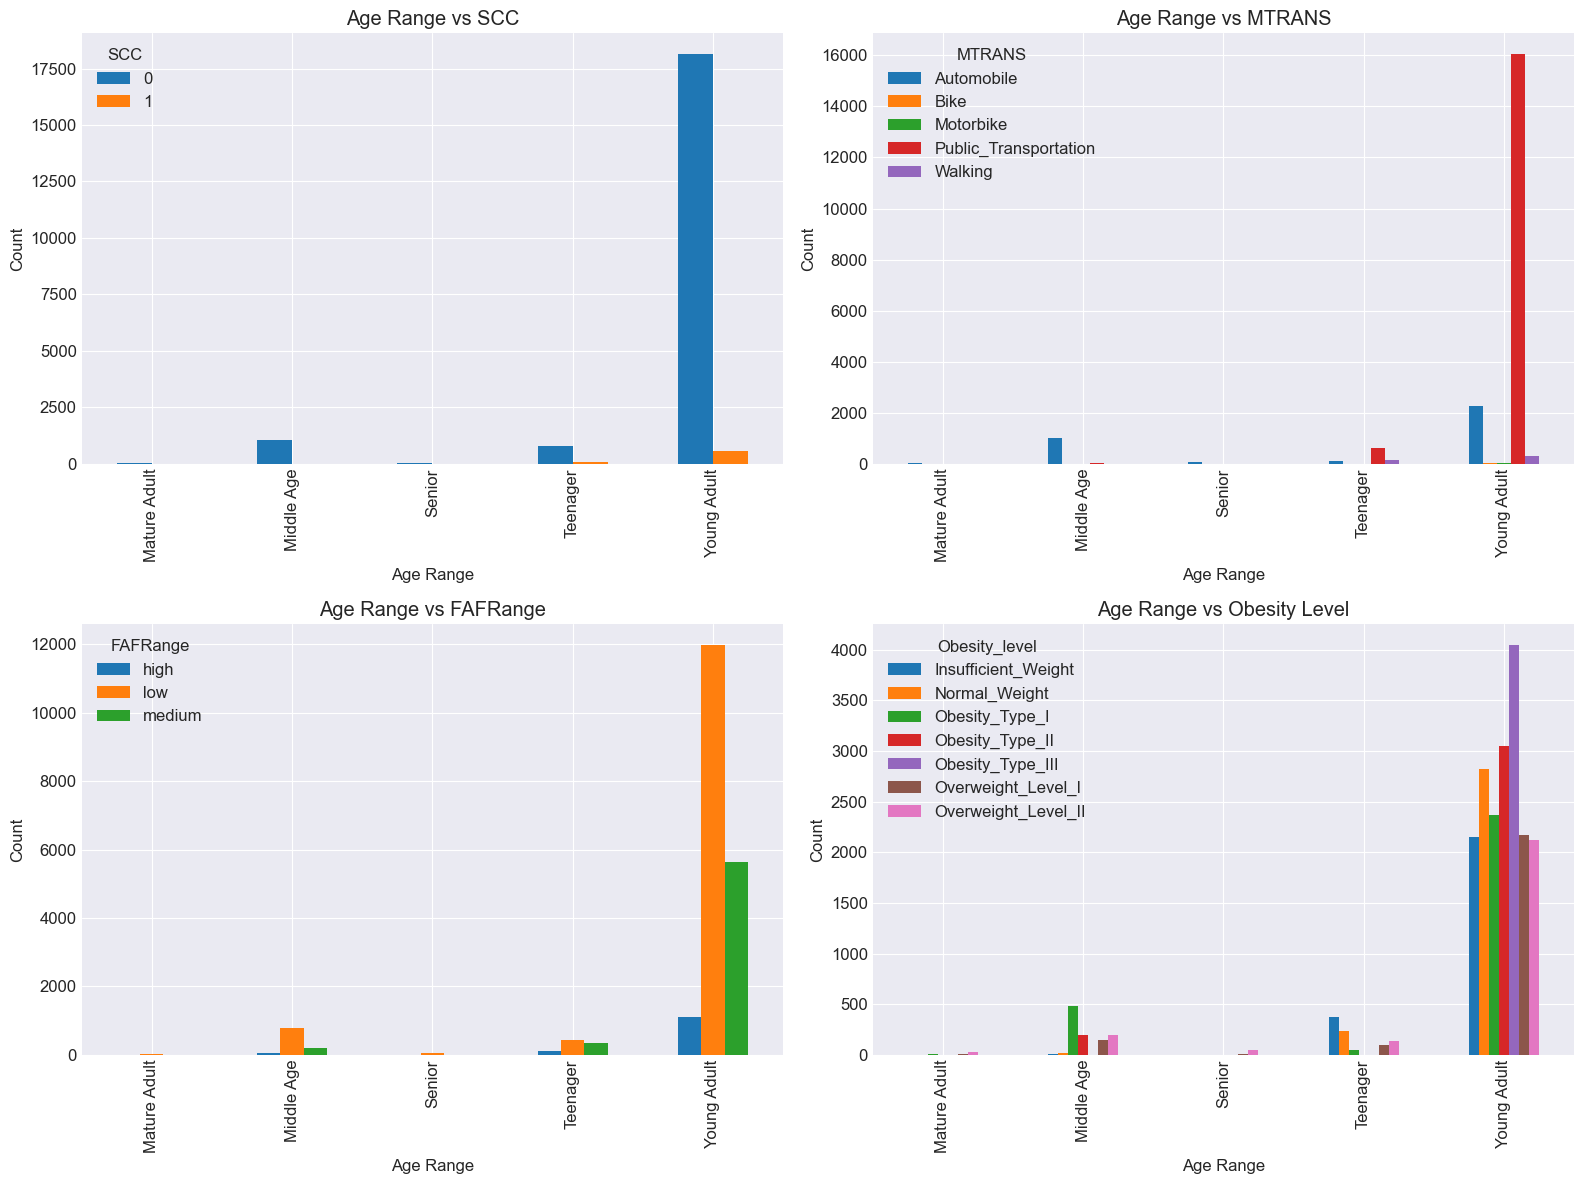

In [43]:
# 创建 2x2 图
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 年龄范围与高热量饮料消耗量的关系
age_scc_counts.pivot(index='AgeRange', columns='SCC', values='count').fillna(0).plot(kind='bar', ax=axs[0, 0])
axs[0, 0].set_title('Age Range vs SCC')
axs[0, 0].set_xlabel('Age Range')
axs[0, 0].set_ylabel('Count')

# 年龄范围与日常交通方式的关系
age_mtrans_counts.pivot(index='AgeRange', columns='MTRANS', values='count').fillna(0).plot(kind='bar', ax=axs[0, 1])
axs[0, 1].set_title('Age Range vs MTRANS')
axs[0, 1].set_xlabel('Age Range')
axs[0, 1].set_ylabel('Count')

# 年龄范围与运动频率的关系
age_faf_counts.pivot(index='AgeRange', columns='FAFRange', values='count').fillna(0).plot(kind='bar', ax=axs[1, 0])
axs[1, 0].set_title('Age Range vs FAFRange')
axs[1, 0].set_xlabel('Age Range')
axs[1, 0].set_ylabel('Count')

# 年龄范围与肥胖水平的关系
age_obesity_counts.pivot(index='AgeRange', columns='Obesity_level', values='count').fillna(0).plot(kind='bar', ax=axs[1, 1])
axs[1, 1].set_title('Age Range vs Obesity Level')
axs[1, 1].set_xlabel('Age Range')
axs[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


##### Report:
- Age Range vs SCC（年龄范围与SCC的关系）
    - 空着：因为不确定0和1分别代表什么

- Age Range vs MTRANS（年龄范围与交通方式的关系）
    - 18-34岁的人群（Young Adult）主要选择公共交通出行（Public_Transportation），人数接近16000人，而其他交通方式如汽车（Automobile）、自行车（Bike）等的选择人数相对较少。

- Age Range vs FAF（年龄范围与FAF的关系）
    - 18-34岁的人群（Young Adult）消耗高热量饮料多，13-17岁人群（Teenager）和35-44岁人群（Middle Age） 其次。

- Age Range vs Obesity Level（年龄范围与肥胖水平的关系）
    - 18-34岁的人群（Young Adult）肥胖问题严重。

>存疑：1. 0/1问题； 2.年龄范围与肥胖水平的关系图，不太合理

#### 年龄分布与肥胖水平关系

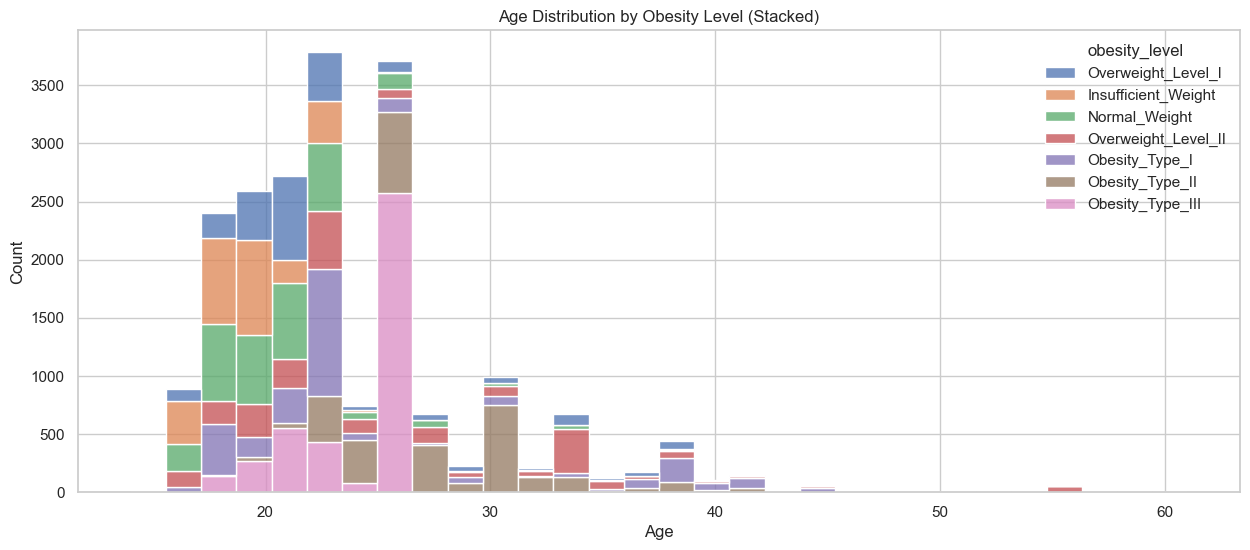

In [44]:
def plot_stacked_age_obesity_distribution(data_df):
     # 将 Spark DataFrame 转换为 Pandas DataFrame
    pandas_df = data_df.select('Age', 'obesity_level').toPandas()
    
    # 设置 seaborn 样式
    sns.set_theme(style="whitegrid")
    
    # 创建堆叠直方图
    plt.figure(figsize=(15, 6))
    sns.histplot(pandas_df, x='Age', hue='obesity_level', multiple='stack', bins=30)
    plt.title('Age Distribution by Obesity Level (Stacked)') # 标题也做了区分
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.show()

plot_stacked_age_obesity_distribution(data)


#### FAVC 分布与肥胖水平的关系

In [45]:
from sklearn.utils import resample

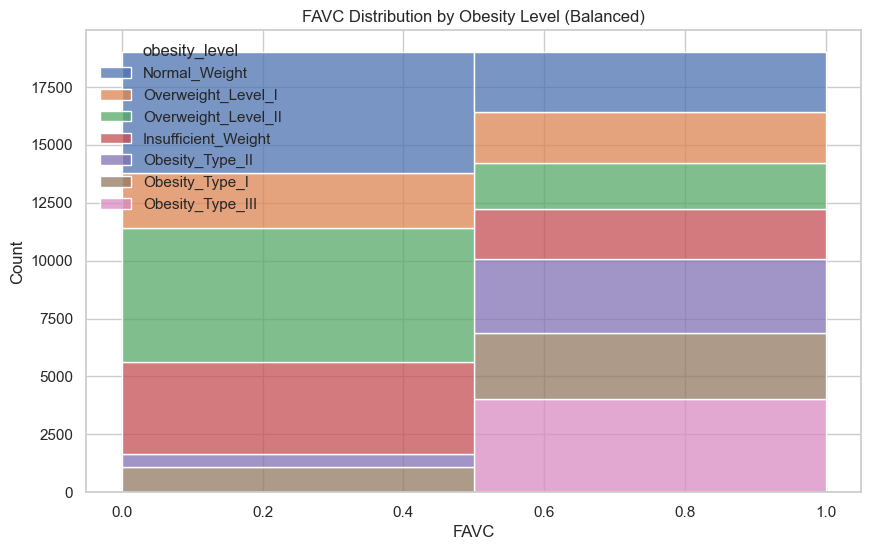

In [46]:
def plot_age_distribution(data_df):
    # 将 Spark DataFrame 转换为 Pandas DataFrame
    pandas_df = data_df.select('FAVC', 'obesity_level').toPandas()
    
    # 根据 FAVC 分离数据为两组
    favc_0 = pandas_df[pandas_df['FAVC'] == 0]
    favc_1 = pandas_df[pandas_df['FAVC'] == 1]
    
    # 对少数类 (FAVC=0) 进行过采样
    # 如果 FAVC=0 是多数类，则此逻辑会将其降采样到少数类的数量。
    # 这里假设 FAVC=0 是少数类且 FAVC=1 是多数类。
    # 更健壮的实现会动态判断多数类和少数类。
    if len(favc_0) < len(favc_1):
        favc_0_upsampled = resample(favc_0, 
                                    replace=True,  # 有放回抽样
                                    n_samples=len(favc_1),  # 匹配多数类样本数量
                                    random_state=42)  # 用于复现性
        # 合并过采样的少数类与多数类
        balanced_df = pd.concat([favc_0_upsampled, favc_1])
    elif len(favc_1) < len(favc_0):
        favc_1_upsampled = resample(favc_1, 
                                    replace=True,  # 有放回抽样
                                    n_samples=len(favc_0),  # 匹配多数类样本数量
                                    random_state=42)  # 用于复现性
        # 合并过采样的少数类与多数类
        balanced_df = pd.concat([favc_0, favc_1_upsampled])
    else: # 数量相等，无需平衡
        balanced_df = pandas_df

    # 设置 seaborn 样式
    sns.set_theme(style="whitegrid")
    
 
    plt.figure(figsize=(10, 6))
    sns.histplot(balanced_df, x='FAVC', hue='obesity_level', multiple='stack', bins=2)
    plt.title('FAVC Distribution by Obesity Level (Balanced)')
    plt.xlabel('FAVC')
    plt.ylabel('Count')
    plt.show()
plot_age_distribution(data)

#### Line Chart


#### 每日耗水量与肥胖水平的关系

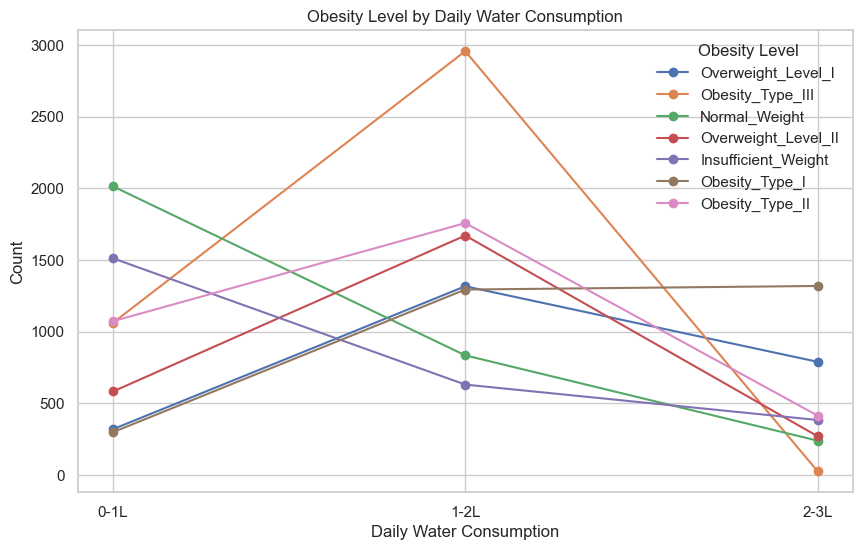

In [47]:
# 统计每个区间内不同肥胖水平的分布情况
obesity_counts = data.groupBy("CH2O_CategoryRange", "Obesity_level").count()

# 将结果转换为 Pandas DataFrame
obesity_counts_pd = obesity_counts.toPandas()

# 绘制折线图
fig, ax = plt.subplots(figsize=(10, 6))

# 获取区间和肥胖水平的标签
categories = obesity_counts_pd['CH2O_CategoryRange'].unique()
obesity_levels = obesity_counts_pd['Obesity_level'].unique()

# 为每个肥胖水平绘制折线图
for level in obesity_levels:
    level_data = obesity_counts_pd[obesity_counts_pd['Obesity_level'] == level]
    ax.plot(categories, level_data['count'], marker='o', label=level)

ax.set_title('Obesity Level by Daily Water Consumption')
ax.set_xlabel('Daily Water Consumption')
ax.set_ylabel('Count')
ax.legend(title='Obesity Level')
plt.show()

>存疑：横坐标顺序

##### 年龄与肥胖水平的关系

estimator='mean'：对于每一个年龄值，这条黑线表示的是该年龄所有对应 obesity_level_num 值的平均值（Mean）

errorbar='sd': 这表示图中深蓝色线周围的浅蓝色区域是 该年龄对应的 obesity_level_num 值的标准差（Standard Deviation）范围

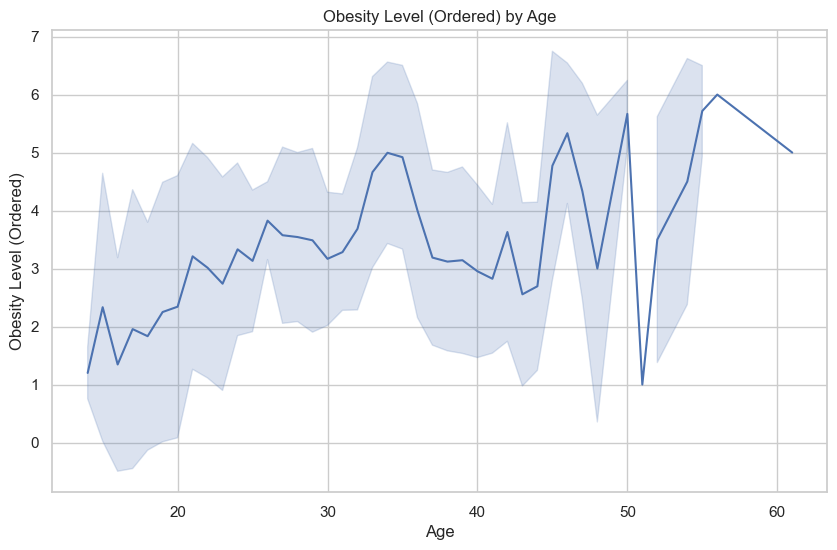

In [48]:
def plot_obesity_age_relationship(data_df):
    # 将肥胖水平映射为数值
    level_map = {
        'Overweight_Level_II': 6,
        'Overweight_Level_I': 5,
        'Obesity_Type_III': 4,
        'Obesity_Type_II': 3,
        'Obesity_Type_I': 2,
        'Normal_Weight': 1,
        'Insufficient_Weight': 0
    }
    
    # 将 Spark DataFrame 转换为 Pandas DataFrame
    pandas_df = data_df.select('Age', 'obesity_level').toPandas()
    pandas_df['obesity_level_num'] = pandas_df['obesity_level'].map(level_map)
    
    # 设置 seaborn 样式
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(x='Age', y='obesity_level_num', data=pandas_df, estimator='mean', errorbar='sd')
    
    plt.title('Obesity Level (Ordered) by Age')
    plt.xlabel('Age')
    plt.ylabel('Obesity Level (Ordered)')
    plt.show()



plot_obesity_age_relationship(data)

#### Scatter Chart

##### 基于性别区分的身高与体重的关系

In [49]:
# 转换为 Pandas DataFrame
df_pd = data.toPandas()

/opt/miniconda3/envs/big_data/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36523 (\N{CJK UNIFIED IDEOGRAPH-8EAB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/big_data/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/big_data/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/big_data/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/big_data/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK 

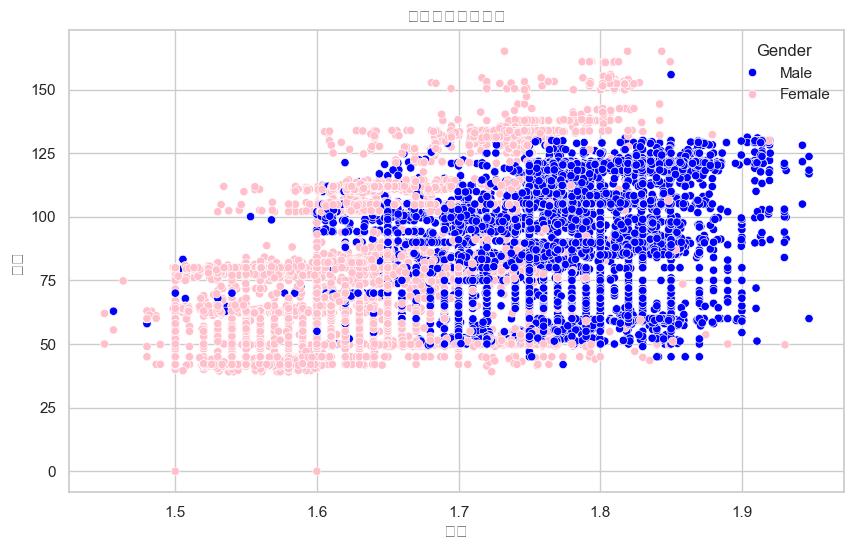

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Height', y='Weight', hue='Gender', data=df_pd , palette={'Male': 'blue', 'Female': 'pink'})
plt.title('身高与体重的关系')
plt.xlabel('身高')
plt.ylabel('体重')
plt.legend(title='Gender')
plt.show()

##### **Report**：
通过观察，发现身高与体重有不明显的正相关

#### 运动频率与每日耗水量的关系

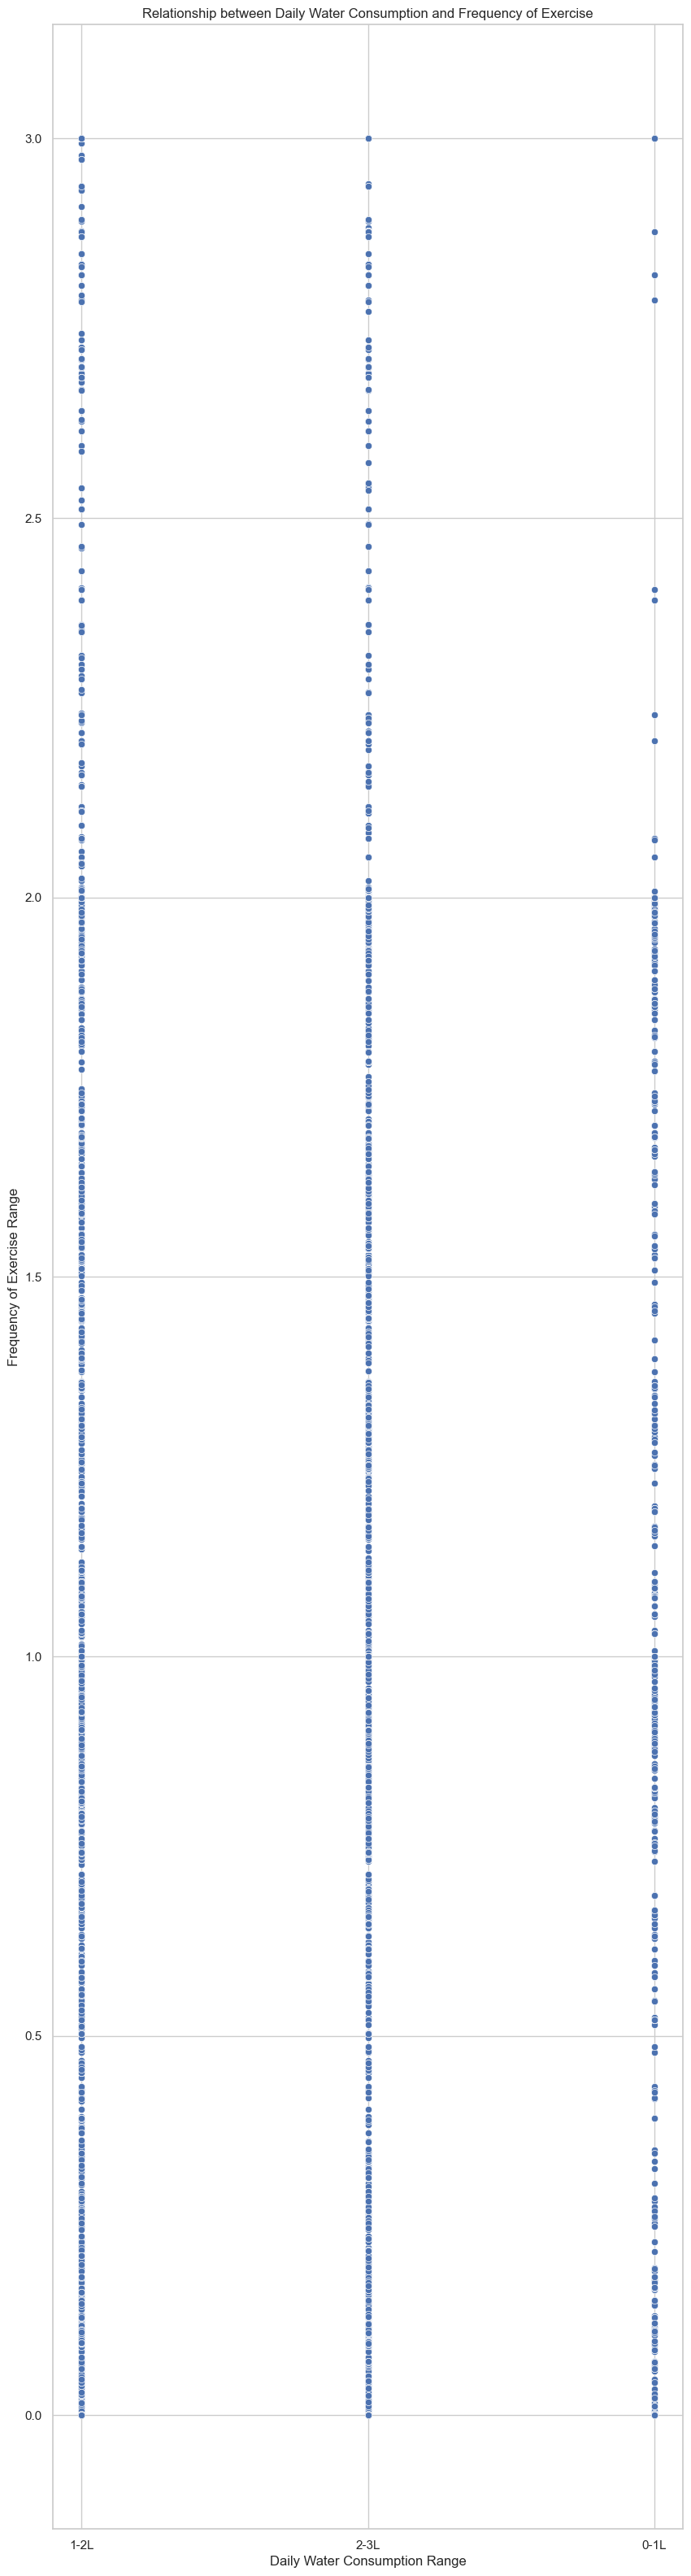

In [51]:
plt.figure(figsize=(10, 40))
sns.scatterplot(x='CH2O_CategoryRange', y='FAF', data=df_pd )
plt.title('Relationship between Daily Water Consumption and Frequency of Exercise')
plt.xlabel('Daily Water Consumption Range')
plt.ylabel('Frequency of Exercise Range')
plt.show()

##### **Report**:

两者没有太明显的关联

#### violin

/var/folders/23/snrgtk4j63j0s4txk_mdvjjr0000gn/T/ipykernel_92231/1662419642.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Obesity_level', y=var, data= df_pd , ax=axes[i], palette='viridis')
/var/folders/23/snrgtk4j63j0s4txk_mdvjjr0000gn/T/ipykernel_92231/1662419642.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Obesity_level', y=var, data= df_pd , ax=axes[i], palette='viridis')
/var/folders/23/snrgtk4j63j0s4txk_mdvjjr0000gn/T/ipykernel_92231/1662419642.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Obesity_l

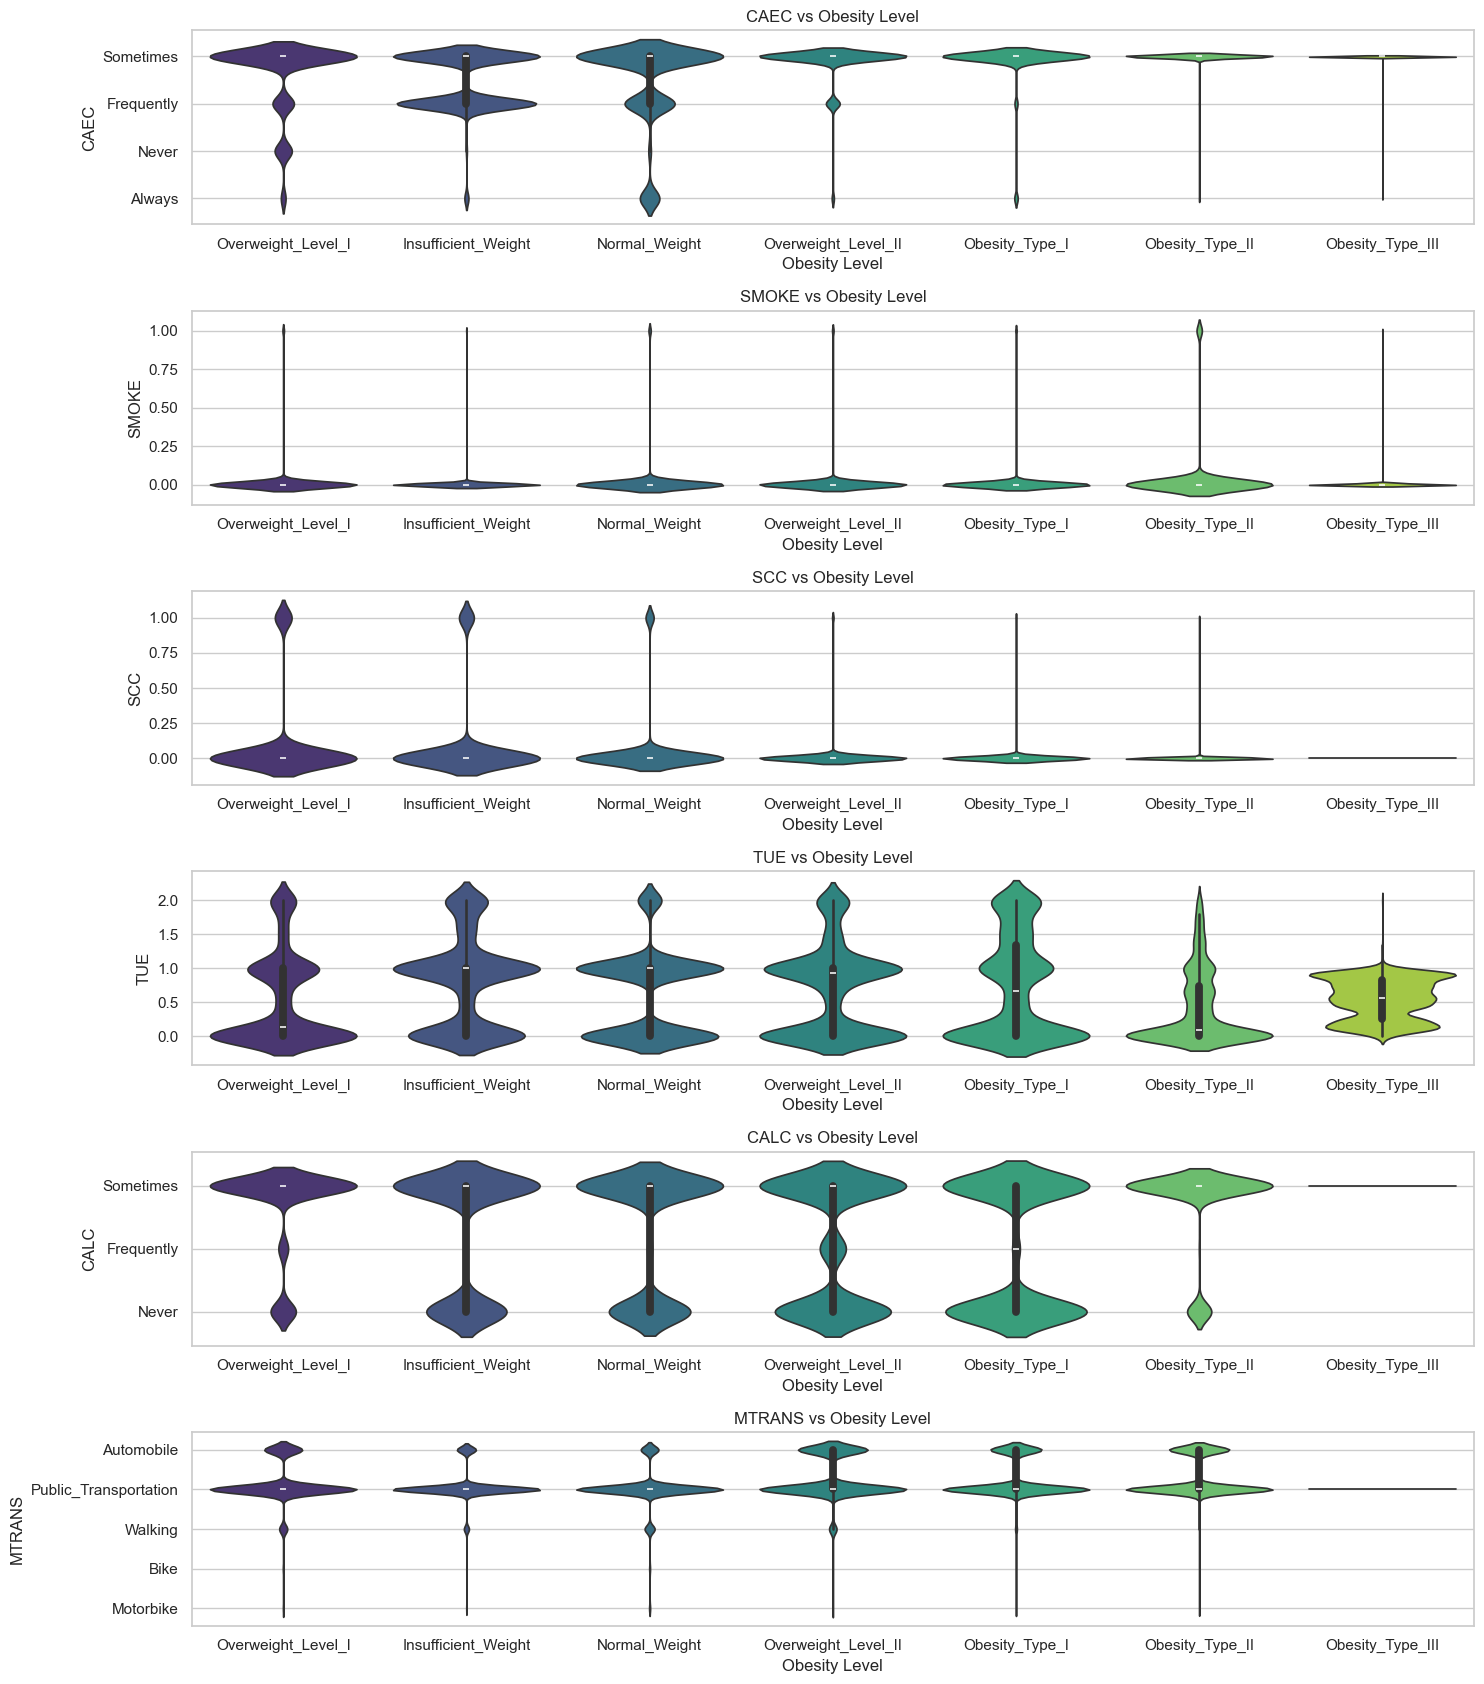

In [52]:
# 创建一个图形和子图
continuous_vars = ['CAEC', 'SMOKE', 'SCC', 'TUE', 'CALC', 'MTRANS']

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(15, 17))
axes = axes.flatten()

# 绘制每个变量的小提琴图
for i, var in enumerate(continuous_vars):
    sns.violinplot(x='Obesity_level', y=var, data= df_pd , ax=axes[i], palette='viridis')
    axes[i].set_title(f'{var} vs Obesity Level')
    axes[i].set_xlabel('Obesity Level')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

##### Report：
- 两餐之间的食品消费（CAEC）：肥胖水平较高的个体更倾向于频繁消费。

- 是否吸烟（SMOKE）：吸烟与肥胖水平之间的关系不明显。

- 高热量饮料消耗量（SCC）：高热量饮料的消耗量在肥胖水平较高的个体中更为常见。

- 使用电子设备的时间（TUE）：使用电子设备的时间与肥胖水平之间的关系较为复杂，但肥胖水平较高的个体倾向于花费更多时间在电子设备上。

- 酒精消耗量（CALC）：未显示出明显的相关性。

- 日常交通方式（MTRANS）：日常交通方式与肥胖水平之间存在一定的关联。肥胖水平较高的个体更可能选择使用汽车，而肥胖水平较低的个体更倾向于步行或骑自行车。

#### Heatmap

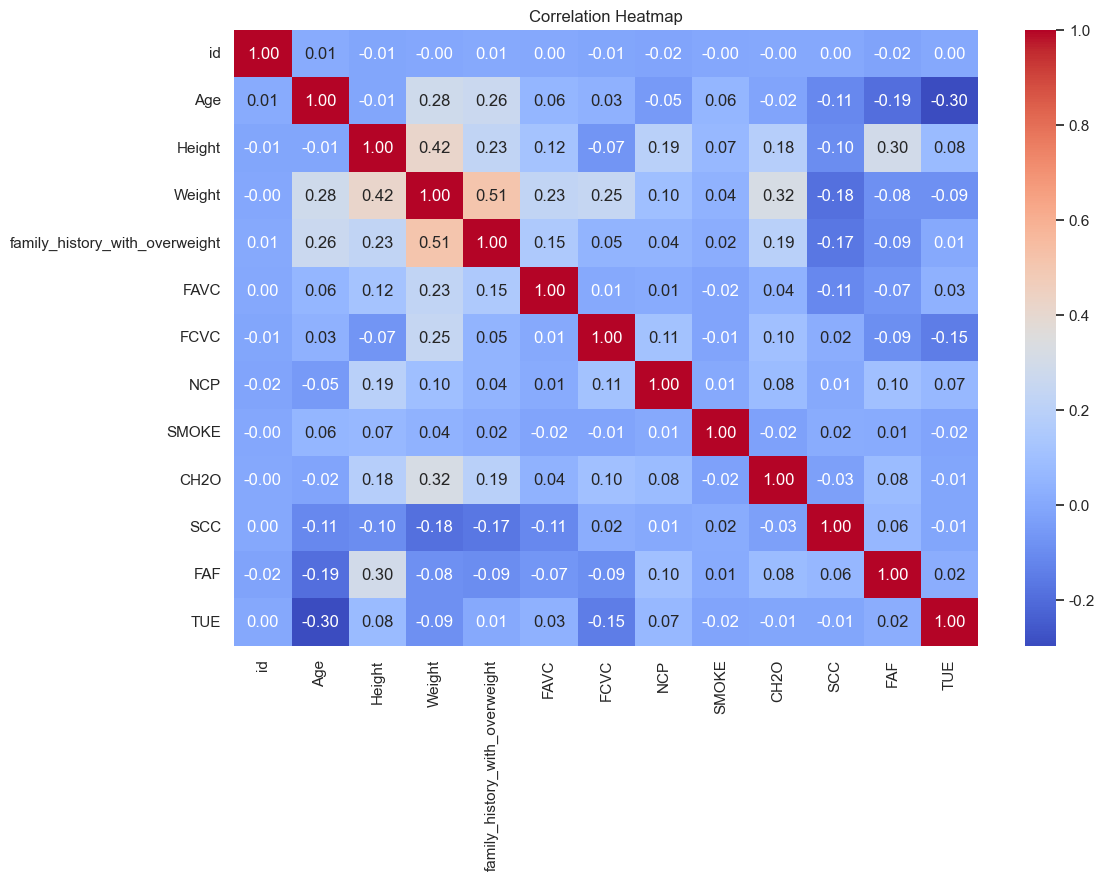

In [53]:
# 选择数值型列
numeric_columns = [col for col, dtype in data.dtypes if dtype in ['int', 'double', 'float']]

# 初始化相关性矩阵
corr_matrix = pd.DataFrame(np.zeros((len(numeric_columns), len(numeric_columns))),
                           index=numeric_columns, columns=numeric_columns)

# 计算每对列之间的相关性
for col1 in numeric_columns:
    for col2 in numeric_columns:
        corr_value = data.stat.corr(col1, col2)
        corr_matrix.loc[col1, col2] = corr_value

# 绘制热力图
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

##### **Report**:

红色表示正相关，蓝色表示负相关，颜色越深，相关性越强。
- 体重（Weight）与身高（Height）：体重与身高之间存在中等程度的正相关（相关系数为 0.42），这表明随着身高的增加，体重也倾向于增加。

- 体重（Weight）与家族肥胖史（family_history_with_overweight）：体重与家族肥胖史之间存在较强的正相关（相关系数为 0.51），这可能表明家族肥胖史对个体体重有显著影响。

- 体重（Weight）与是否频繁食用高热量食物（FAVC）：体重与是否频繁食用高热量食物之间存在中等程度的正相关（相关系数为 0.51），这表明频繁食用高热量食物可能增加体重。

- 年龄（Age）与使用电子设备的时间（TUE）：年龄与使用电子设备的时间之间存在较强的负相关（相关系数为 -0.30），这可能表明随着年龄的增长，人们使用电子设备的时间减少。

- 运动频率（FAF）与年龄（Age）：运动频率与年龄之间存在中等程度的负相关（相关系数为 -0.19），这可能表明随着年龄的增长，人们的运动频率降低。

- 每日耗水量（CH2O）与高热量饮料消耗量（SCC）：每日耗水量与高热量饮料消耗量之间存在中等程度的负相关（相关系数为 -0.03），这可能表明高热量饮料的消耗可能会减少每日的总耗水量。

#### Density

#### FCVC（食用蔬菜的频次）和 NCP（食用主餐的次数）之间的关系

TypeError: object of type 'Column' has no len()
Output is truncated. --> 这个错误是因为尝试在 PySpark DataFrame 上直接使用 Seaborn 的 kdeplot 函数，而 kdeplot 需要一个 Pandas DataFrame 作为输入。

In [54]:
# 获取唯一值
ncp_categories = data.select("NCP_CategoryRange").distinct().rdd.flatMap(lambda x: x).collect()

Pandas 有接口画图 和 matplotlib以及seaborn 是集成关系（合作）

pyspark本身不画图

In [55]:
# 转换为 Pandas DataFrame
df_pd = data.toPandas()

/opt/miniconda3/envs/big_data/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


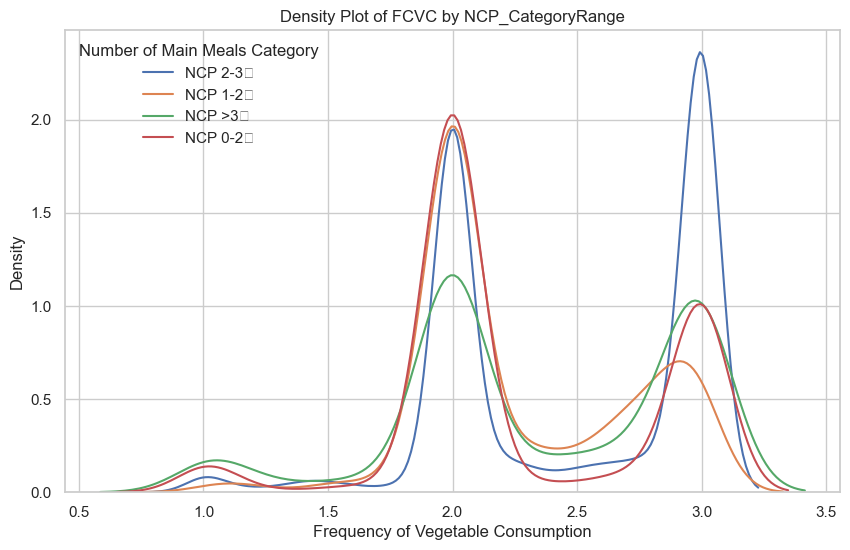

In [56]:
# 绘制密度图
plt.figure(figsize=(10, 6))
for ncp_category in ncp_categories:
    subset = df_pd [df_pd ['NCP_CategoryRange'] == ncp_category]
    sns.kdeplot(subset['FCVC'], label=f'NCP {ncp_category}')
plt.title('Density Plot of FCVC by NCP_CategoryRange')
plt.xlabel('Frequency of Vegetable Consumption')
plt.ylabel('Density')
plt.legend(title='Number of Main Meals Category')
plt.show()

##### **Report**：
- NCP 为 0-2次的主餐消费者在 FCVC 上呈现出双峰分布，表明这一群体在蔬菜消费上存在两种不同的习惯。

- NCP 为 1-2次和 2-3次的主餐消费者在 FCVC 上的分布较为集中，且峰值出现在较高的 FCVC 值，显示出较为一致的蔬菜消费习惯。

- NCP 超过3次的主餐消费者在 FCVC 上的分布较为分散，但同样显示出一定的集中趋势。

In [57]:
# 停止 SparkSession
# spark.stop()
# print("SparkSession 已停止。")

## Model

In [58]:
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

obesity_level_map = {
    'Overweight_Level_II': 6,
    'Overweight_Level_I': 5,
    'Obesity_Type_III': 4,
    'Obesity_Type_II': 3,
    'Obesity_Type_I': 2,
    'Normal_Weight': 1,
    'Insufficient_Weight': 0
}

# transform obesity_level to numerical values
# define a UDF to map obesity_level to numerical values
map_obesity_level_udf = udf(lambda x: obesity_level_map.get(x), IntegerType())
merged_df= data.withColumn("obesity_level", map_obesity_level_udf("obesity_level"))

In [59]:
merged_df.select("obesity_level").distinct().show()

+-------------+
|obesity_level|
+-------------+
|            1|
|            6|
|            3|
|            5|
|            4|
|            2|
|            0|
+-------------+



In [60]:
from pyspark.ml.feature import StringIndexer,OneHotEncoder,VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier,RandomForestClassifier,GBTClassifier,NaiveBayes
from pyspark.ml import Pipeline

In [61]:
# 原来的：
# no_num_cols = ['Gender', 'family_history_with_overweight','FAVC','FCVC', 'NCP', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
# num_cols = ['Age','Height','Weight','CH2O','FAF','TUE']

# 真正的字符串/类别列
no_num_cols = ['Gender', 'family_history_with_overweight',
               'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

# FCVC、NCP、FAVC 是数值型离散变量，放到 num_cols 里
num_cols = ['Age','Height','Weight','CH2O','FAF','TUE','FCVC','NCP','FAVC']

labels_cols = ['obesity_level']
obesity_selected_df = merged_df.select(num_cols+no_num_cols+labels_cols)


In [62]:
# string indexer
input_cols = no_num_cols
output_string_indexer = [i + '_index' for i in input_cols]
# 原来的：
# string_indexer = StringIndexer(inputCols=input_cols, outputCols=output_string_indexer)

string_indexer = StringIndexer(inputCols=no_num_cols,
                               outputCols=[c + '_index' for c in no_num_cols],
                               handleInvalid='keep')   # 防止 unseen label

In [63]:
merged_df.describe().show()

+-------+------------------+------+------------------+-------------------+------------------+------------------------------+-------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+----------+----------+------------------+------------+------------------+--------+-----------------+
|summary|                id|Gender|               Age|             Height|            Weight|family_history_with_overweight|               FAVC|              FCVC|               NCP|     CAEC|               SMOKE|              CH2O|                SCC|               FAF|               TUE|      CALC|    MTRANS|     obesity_level|    AgeRange|CH2O_CategoryRange|FAFRange|NCP_CategoryRange|
+-------+------------------+------+------------------+-------------------+------------------+------------------------------+-------------------+------------------+------------------+---------+--------------------+-----

In [64]:
# qick check the corr for each attributes
indexed_df = string_indexer.fit(obesity_selected_df).transform(obesity_selected_df)
obesity_level_corr = {}
for the_col in output_string_indexer + num_cols:
    obesity_level_corr[the_col] = [indexed_df.corr(the_col,'obesity_level')]
obesity_level_corr
    

{'Gender_index': [0.047112518814464814],
 'family_history_with_overweight_index': [-0.32117064964968745],
 'CAEC_index': [-0.18027062582653341],
 'SMOKE_index': [-0.0013443879646965456],
 'SCC_index': [-0.06504128289250459],
 'CALC_index': [-0.05272317755679189],
 'MTRANS_index': [0.03761191014712271],
 'Age': [0.28243146798833196],
 'Height': [0.06192361081155844],
 'Weight': [0.4322960714586845],
 'CH2O': [0.18688674128820024],
 'FAF': [-0.0967661904205512],
 'TUE': [-0.07626784377125798],
 'FCVC': [0.040619362686883494],
 'NCP': [-0.09128744001611719],
 'FAVC': [0.010022828669270284]}

In [65]:
# one_hot
# 原来的：
# input_cols = output_string_indexer
# output_oneHot = [i + '_vec' for i in input_cols]
# one_hot_encoder = OneHotEncoder(inputCols=input_cols, outputCols=output_oneHot)

output_string_indexer = [c + '_index' for c in no_num_cols]
output_oneHot = [c + '_vec' for c in output_string_indexer]
one_hot_encoder = OneHotEncoder(inputCols=output_string_indexer,
                                outputCols=output_oneHot)

In [66]:
# assembling
final_cols = output_oneHot + num_cols
assembler = VectorAssembler(inputCols=final_cols, outputCol="features")

In [67]:
dtc = DecisionTreeClassifier(featuresCol="features",labelCol='obesity_level')
rfc = RandomForestClassifier(featuresCol="features", labelCol='obesity_level')
# gbt only support 2 binary labels 
# gbt_arr = GBTClassifier(featuresCol="features",labelCol='obesity_level')


In [68]:
dt_pip = Pipeline(stages=[string_indexer, one_hot_encoder,assembler, dtc])
rfc_pip = Pipeline(stages=[string_indexer, one_hot_encoder,assembler,rfc])
# gbt_pip  = Pipeline(stages=[one_hot_encoder,assembler,gbt_arr])

In [69]:
df_train, df_test = obesity_selected_df.randomSplit([0.8,0.2],1)


In [70]:
dt_model = dt_pip.fit(df_train)
dt_predcition = dt_model.transform(df_test)

In [71]:
rf_model = rfc_pip.fit(df_train)
rf_prediction = rf_model.transform(df_test)

In [72]:
from pyspark.sql.functions import count, col

In [73]:
dt_predcition.groupBy('obesity_level','prediction')\
                 .agg(count(col('prediction')).alias('count'))\
                 .select(col('obesity_level').alias('label(obesity_level)'),'prediction','count')\
                 .show()


+--------------------+----------+-----+
|label(obesity_level)|prediction|count|
+--------------------+----------+-----+
|                   1|       6.0|    2|
|                   2|       4.0|    5|
|                   1|       0.0|   81|
|                   0|       2.0|    1|
|                   3|       4.0|    1|
|                   4|       4.0|  800|
|                   5|       5.0|  364|
|                   5|       2.0|    5|
|                   6|       6.0|  362|
|                   1|       5.0|  140|
|                   0|       3.0|    1|
|                   0|       0.0|  466|
|                   5|       1.0|   51|
|                   6|       5.0|  117|
|                   1|       2.0|    1|
|                   2|       3.0|   17|
|                   3|       2.0|   45|
|                   4|       5.0|    1|
|                   3|       3.0|  579|
|                   3|       5.0|    1|
+--------------------+----------+-----+
only showing top 20 rows


报错根源

obesity_level 列在训练阶段被 StringIndexer 转成数字索引，

而 prediction 列是模型输出的 连续型预测值（如 1.943927），

它并不是索引，于是被当成“从未见过的 label”抛错。

In [74]:
rf_prediction.groupBy('obesity_level','prediction')\
                 .agg(count(col('prediction')).alias('count'))\
                 .select(col('obesity_level').alias('label(obesity_level)'),'prediction','count')\
                 .show(30)

+--------------------+----------+-----+
|label(obesity_level)|prediction|count|
+--------------------+----------+-----+
|                   2|       1.0|   20|
|                   1|       6.0|   11|
|                   4|       1.0|    2|
|                   2|       4.0|    7|
|                   1|       0.0|   68|
|                   0|       2.0|    1|
|                   3|       4.0|    1|
|                   6|       4.0|    1|
|                   5|       4.0|    4|
|                   4|       4.0|  800|
|                   5|       5.0|  119|
|                   5|       2.0|   36|
|                   6|       6.0|  291|
|                   1|       5.0|   12|
|                   0|       3.0|    1|
|                   0|       0.0|  395|
|                   5|       1.0|  219|
|                   6|       5.0|   22|
|                   0|       4.0|    1|
|                   1|       2.0|    3|
|                   2|       3.0|   72|
|                   3|       2.0|   11|


In [75]:
# accuracy
# precision
# recall
# f1

In [76]:
# Compute the AUC, accuracy, recall, and precision for the obesity_level label from each model testing result using pyspark MLlib/ML APIs.
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

dt_accuracy = evaluator_accuracy.evaluate(dt_predcition.withColumn('label',col('obesity_level')))
rf_accuracy = evaluator_accuracy.evaluate(rf_prediction.withColumn('label',col('obesity_level')))
dt_precision = evaluator_precision.evaluate(dt_predcition.withColumn('label',col('obesity_level')))
rf_precision = evaluator_precision.evaluate(rf_prediction.withColumn('label',col('obesity_level')))
dt_recall = evaluator_recall.evaluate(dt_predcition.withColumn('label',col('obesity_level')))
rf_recall = evaluator_recall.evaluate(rf_prediction.withColumn('label',col('obesity_level')))
dt_f1 = evaluator_f1.evaluate(dt_predcition.withColumn('label',col('obesity_level')))
rf_f1 = evaluator_f1.evaluate(rf_prediction.withColumn('label',col('obesity_level')))



print(
f"""
dt_accuracy: {dt_accuracy}
rf_accuracy: {rf_accuracy}
dt_precision: {dt_precision}
rf_precision: {rf_precision}
dt_recall: {dt_recall}
rf_recall: {rf_recall}
dt_f1: {dt_f1}
rf_f1: {rf_f1}
"""
)


dt_accuracy: 0.8286814244465832
rf_accuracy: 0.7690086621751684
dt_precision: 0.840326417997556
rf_precision: 0.7800396310174041
dt_recall: 0.8286814244465832
rf_recall: 0.7690086621751684
dt_f1: 0.8303688703403929
rf_f1: 0.7543946207588093



accuracy计算简单，但是很容易受样本不均衡的影响。比如，100个样本，正样本90，全部预测为正样本，accuracy=90%，显然，这样的模型是无意义的
precision和recall很难放在一起衡量模型。因为在实际情况中，要增加precision，模型严格一点，只把很确认的值判断为positive，这样recall就很低。相反的，提高recall，尽可能多的判为positive，这样precision就会降低。为了均衡鱼与熊掌，F1 score就是对他们做了一个调和。
precision和recall这两个指标在使用的时候，要根据实际场景选择。比如地震预测，就可以牺牲precision要高的recall，嫌疑人定罪问题就要搞得precision。

In [77]:
dt_model.save("./dt_model")

StringIndexer,OneHotEncoder,VectorAssembler来自 ml 这个包

VectorAssembler将所有属性压成一列

## note1：

（1）机器学习解决了什么问题？ 分类和回归

（2）数据集清洗 --> 1.数字/数值类型 ； 2.【分类】字符串类型（eg. 肥胖水平）

（3）由于string无法直接训练 --> pyspark 不支持

解决办法：分类转数字 同时 避免数字大小之分对结果造成影响

- string indexer ：将 字符串 转换为 数值型
- one-hot ：进一步将 String Indexer生成的整数索引 抽象成矩阵 --> 无大小之分
- Assembling : 将分散的特征列组装为一整个特征向量
- pipelines（如同管道包含 string indexer 和 one-hot）和 数据集 结合，然后模型会据此训练

   

## note2：

（1）SVM（决策树） 既可以用于回归用能用于分类，主要是分类
1. 分为二分类和多种分类
2. 其算法有很多种，但是目的都是：一直在降低熵值

（2）信息增量越小，熵值越大
- 熵：代表不确定性，熵越大意味着不确定性越强
- 信息增量越大越好 ：H1-H2      
1. dataset整体熵值 H1
2. 每种特征下的熵值 H2 :计算出每个熵值，然后按比率算
3. 把信息增量最大的，作为根结点
4. 该特征有几个类别，就有几个分支（eg：时间段：黄昏、中午、日出）
- 如果黄昏对应的结果都为 no， 则 直接 no。 如果有yes的存在，则还会有分支。
5. 对最终结论无影响的特征不会出现在树里


（3）ID3 （其中一种算法）
1. 判断树的方法：无法构成循环（构成循环就变成图）
2. 叶子节点是分类本身，结点是分类的属性
3. 求和公式中：n代表终点值，i代表起始值
- n=5，i=4:就是两坨 --> i=4的这一坨 + i=5的这一坨
4. 计算熵的公式 H（S）：
- pi 代表概率
- n由分了几个类决定（二分类，n=2）
5. 构建决策树的结点：选特征值计算出熵小的。


（4）其他：
- 在数据集太小的情况下 随机森林（民主投票，哪儿个多选哪儿个）不适用 test 和 train
- 不同算法只是决定结点，决策树本身是个过于笃定的模型，容易过拟合
- 列名又称为特征，分类特征的值称为 类别/分类值/水平。模型的输入是特征，模型的输出是标签。

（1）机器学习解决了什么问题？ 分类和回归

（2）数据集清洗 --> 1.数字/数值类型 ； 2.【分类】字符串类型（eg. 肥胖水平）

（3）由于string无法直接训练 --> pyspark 不支持

解决办法：分类转数字 同时 避免数字大小之分对结果造成影响

- string indexer ：将 字符串 转换为 数值型
- one-hot ：进一步将 String Indexer生成的整数索引 抽象成矩阵 --> 无大小之分
- Assembling : 将分散的特征列组装为一整个特征向量
- pipelines（如同管道包含 string indexer 和 one-hot）和 数据集 结合，然后模型会据此训练

   